In [2]:
import dual_autodiff as df
from dual_autodiff import Dual
import math
import numpy as np
import matplotlib.pyplot as plt
import time

### Dual differentiation

In [3]:
# define x=1.5 as Dual(1.5,1) because then the dual part will be the derivative of f at x=1.5
x=Dual(1.5,1)

# define the function
def f(x):
    return (x.sin()).log()+x*x*(x.cos())

# print the result where the dual part will be the derivative of the function at x=1.5
print(f(x))

0.15665054756073515 - 1.9612372705533612ε


### Numeric differentiation

In [4]:
def func(x):
    return math.log(math.sin(x))+(math.cos(x))*x**2

def numderiv(f, x0, h):
    return (f(x0 + h) - f(x0)) / h

print(numderiv(func, 1.5, 1e-3))

-1.9647418175186004


### Analytic differentiation

In [5]:
def deriv_f(x):
    return (math.cos(x) / math.sin(x)) + 2*x*math.cos(x) - math.sin(x)*x**2

print(deriv_f(1.5))

-1.9612372705533612


### Comparison

In [6]:
# check that the derivative obtained from Dual number is machine-precision equal to the analytical derivative
f(x).dual == deriv_f(1.5)

np.True_

In [7]:
times_list = []
deriv_list = []
for k in range(1,10):
    start_time = time.time()
    calc_deriv = numderiv(func, 1.5, 10**(-k))
    times_list.append(time.time() - start_time)
    deriv_list.append(calc_deriv)

deriv_abs_error = np.abs(np.array(deriv_list) - deriv_f(1.5))

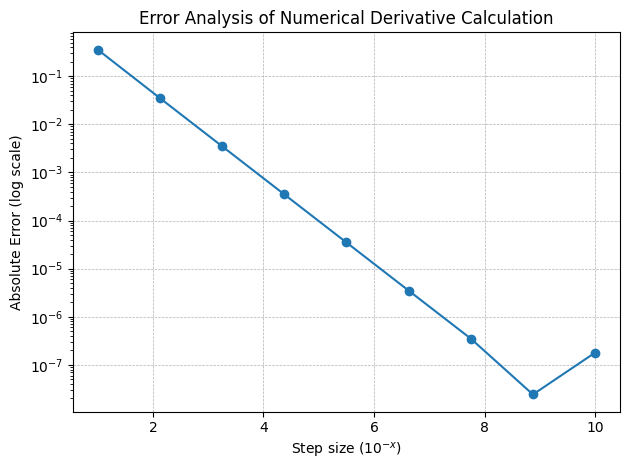

In [8]:
x = np.linspace(1,10,9)
plt.plot(x, deriv_abs_error, marker='o', markersize=6)
plt.yscale('log')
plt.xlabel(r'Step size ($10^{-x}$)')
plt.ylabel('Absolute Error (log scale)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.title('Error Analysis of Numerical Derivative Calculation')
plt.tight_layout()

As expected, the error of the numerical calculated derivative gets smaller as the step size decreases. 
The bump at 10**(-10) as the overflow seems to happen at that point.

In [9]:
%timeit numderiv(func, 1.5, 1e-6) #numerical differentiation with value that gives very small error
%timeit f(Dual(1.5,1)) #dual differentiation
%timeit deriv_f(1.5) #analytical derivative calculation

450 ns ± 1.64 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
3.48 µs ± 11.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
267 ns ± 1.06 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


As expected, numerical derivative calculation takes longer than analytical calculation.
However, it may seem surprising at first that Dual calculation takes longer than both of those. However, that is because we're calculating both the real and dual parts of the function.

Nevertheless, dual differentiation provides exact results while numerical differentiation - only an approximation. And for Neural Networks, the gradient is used for optimization, so using dual numbers ensures that the derivatives are exact, which leads to better training.


To understand another the benefit of the dual auto-differentiation, we might need to investigate what implementation fo dual numbers means to the Neural Networks: it allows for both function value and its derivative calculation in a single forward pass while using numerical derivatives leads to back-propagation, in this scenario dual auto-differentiation implementation might imply performance advantage in terms of time as well.

Dual differentiation vs. numerical differentiation
3.48 µs = 3480 ns, so 3480 ns : 450 ns ~ 7.7 times slower

In [ ]:
# time this operation
x = np.linspace(1, 2, 100)
%timeit np.array([numderiv(func, item, 1e-6) for item in x])

621 µs ± 5.44 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
# time dual differentiation of 100 points 
x = np.linspace(1, 2, 100)
%timeit np.array([f(Dual(item,1)) for item in x])

3.94 ms ± 14.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Although, one can find that individual calculation of a numeric derivative of our function is faster than the calculation of this derivative using dual number. Let's take a look at the demonstration of error accumulation when using numerical derivatives

Text(0.5, 0, 'Number of points ($10^x$)')

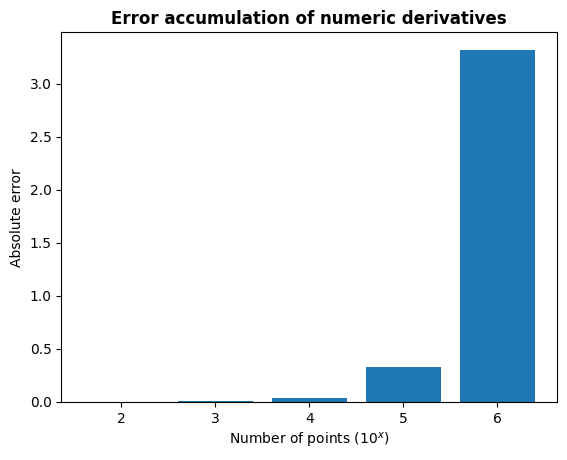

In [30]:
# compute numerical and dual derivatives for different number of points
numpoints = [2, 3, 4, 5, 6]
errors = []

for num in numpoints:
    x = np.linspace(1,2,10**num)

    derivs = []
    derivsDual = []

    for item in x:
        derivs.append(numderiv(func, item, 1e-6))
        derivsDual.append(f(Dual(item,1)).dual)
    
    # compute the absolute error for each point and add them up
    overallError = np.sum(np.abs(np.array(derivs)-np.array(derivsDual)))
    errors.append(overallError)

plt.bar(numpoints, errors)
plt.title("Error accumulation of numeric derivatives", fontweight='bold')
plt.ylabel("Absolute error")
plt.xlabel(r"Number of points ($10^x$)")


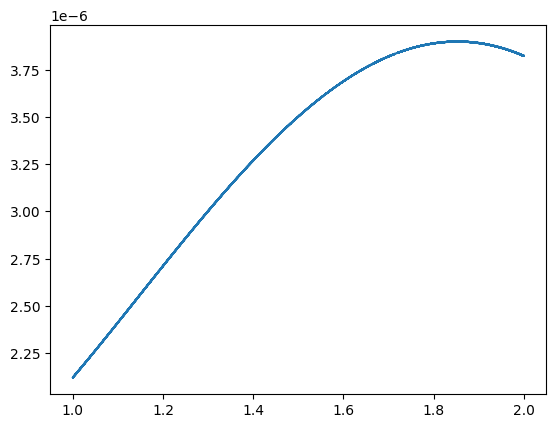

In [32]:
#plot the absolute difference as dual is exact answer up to machine-precision
plt.plot(x, np.abs(np.array(derivs)-np.array(derivsDual)))